In [2]:
import pandas as pd
import missingno as msno
import fancyimpute as fci
import matplotlib.pyplot as plt

data = pd.read_csv("../0_DataPreparation/data.csv")

<Axes: >

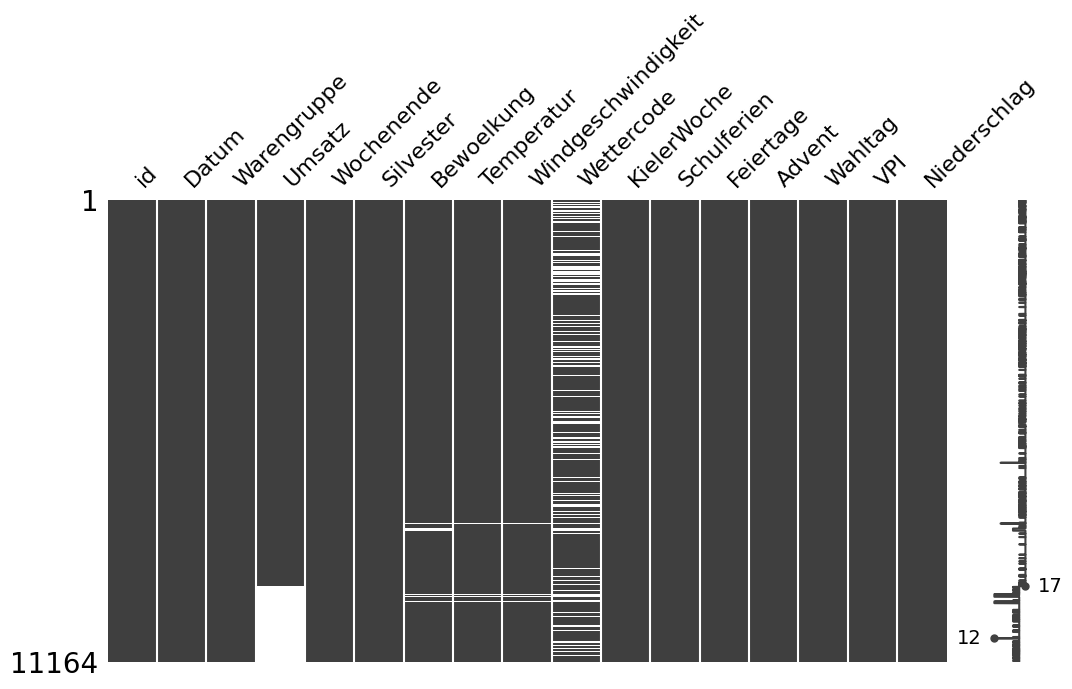

In [3]:
msno.matrix(data, figsize=(12, 6), sparkline=True)

<Axes: >

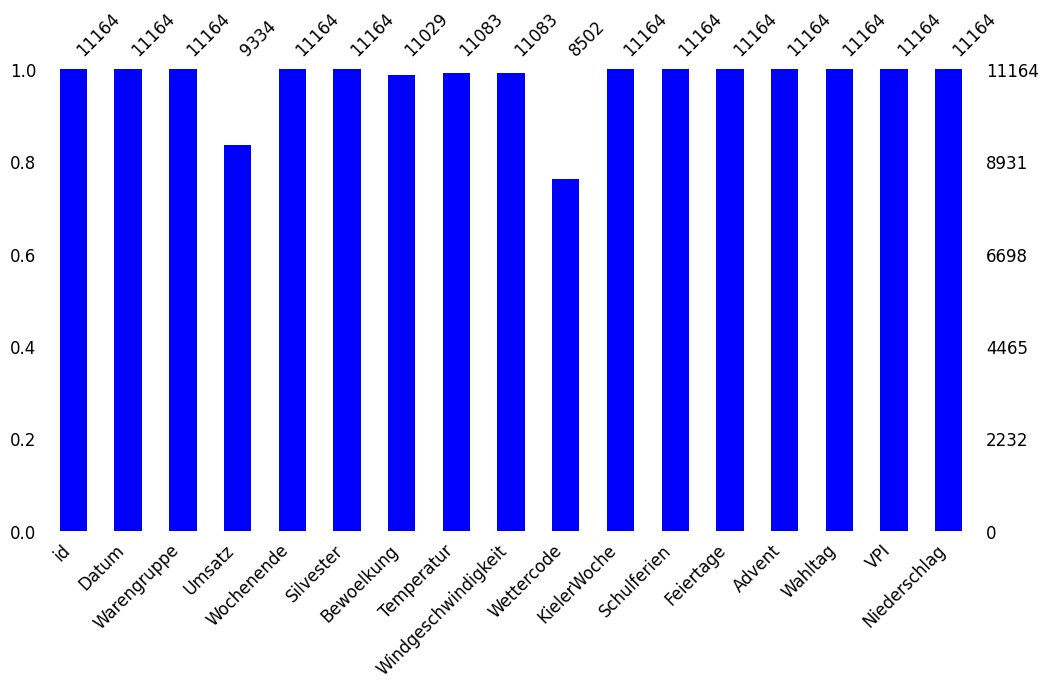

In [4]:
msno.bar(data, figsize=(12, 6), color="blue", fontsize=12)

<Axes: >

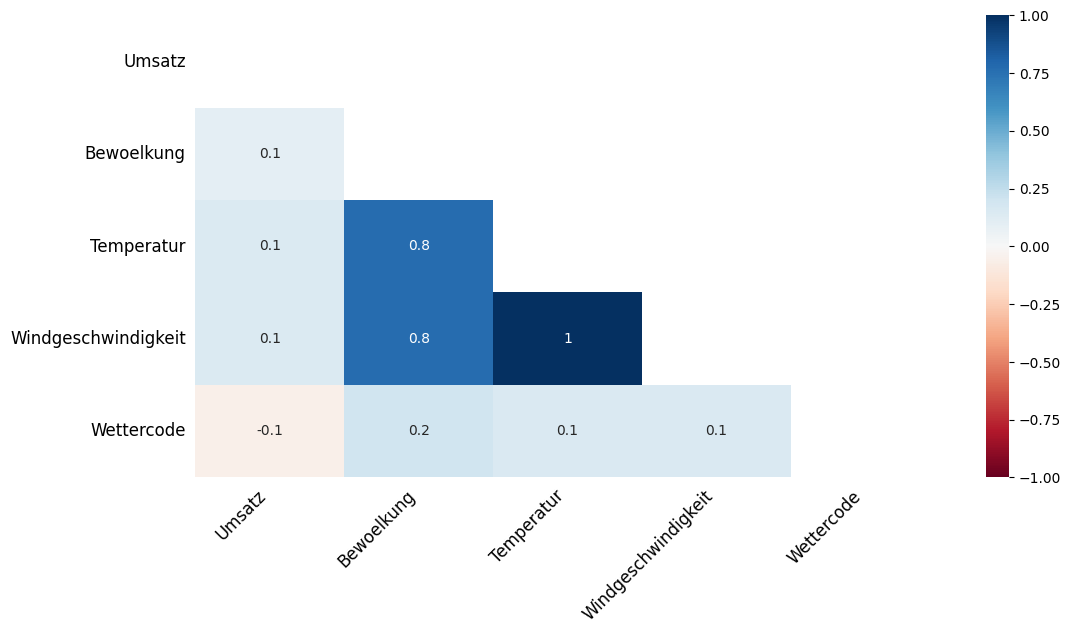

In [5]:
msno.heatmap(data, figsize=(12, 6), fontsize=12)

<Axes: >

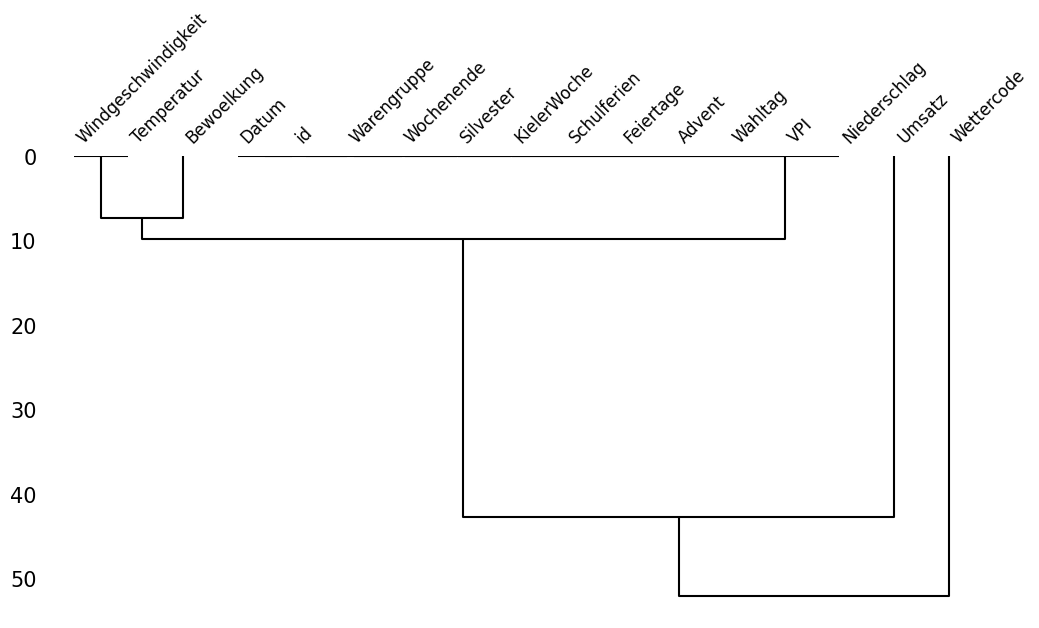

In [6]:
msno.dendrogram(data, figsize=(12, 6), fontsize=12)

c:\Users\anton\Documents\Studium\Data Science\bakery-sales-prediction-group-3\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\anton\Documents\Studium\Data Science\bakery-sales-prediction-group-3\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\anton\Documents\Studium\Data Science\bakery-sales-prediction-group-3\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Imputing row 1/11164 with 0 missing, elapsed time: 10.558
Imputing row 101/11164 with 1 missing, elapsed time: 10.565
Imputing row 201/11164 with 0 missing, elapsed time: 10.565
Imputing row 301/11164 with 0 missing, elapsed time: 10.565
Imputing row 401/11164 with 1 missing, elapsed time: 10.565
Imputing row 501/11164 with 1 missing, elapsed time: 10.576
Imputing row 601/11164 with 0 missing, elapsed time: 10.580
Imputing row 701/11164 with 0 missing, elapsed time: 10.580
Imputing row 801/11164 with 0 missing, elapsed time: 10.580
Imputing row 901/11164 with 0 missing, elapsed time: 10.580
Imputing row 1001/11164 with 0 missing, elapsed time: 10.580
Imputing row 1101/11164 with 0 missing, elapsed time: 10.580
Imputing row 1201/11164 with 0 missing, elapsed time: 10.580
Imputing row 1301/11164 with 0 missing, elapsed time: 10.580
Imputing row 1401/11164 with 0 missing, elapsed time: 10.592
Imputing row 1501/11164 with 0 missing, elapsed time: 10.595
Imputing row 1601/11164 with 1 missi

<Axes: >

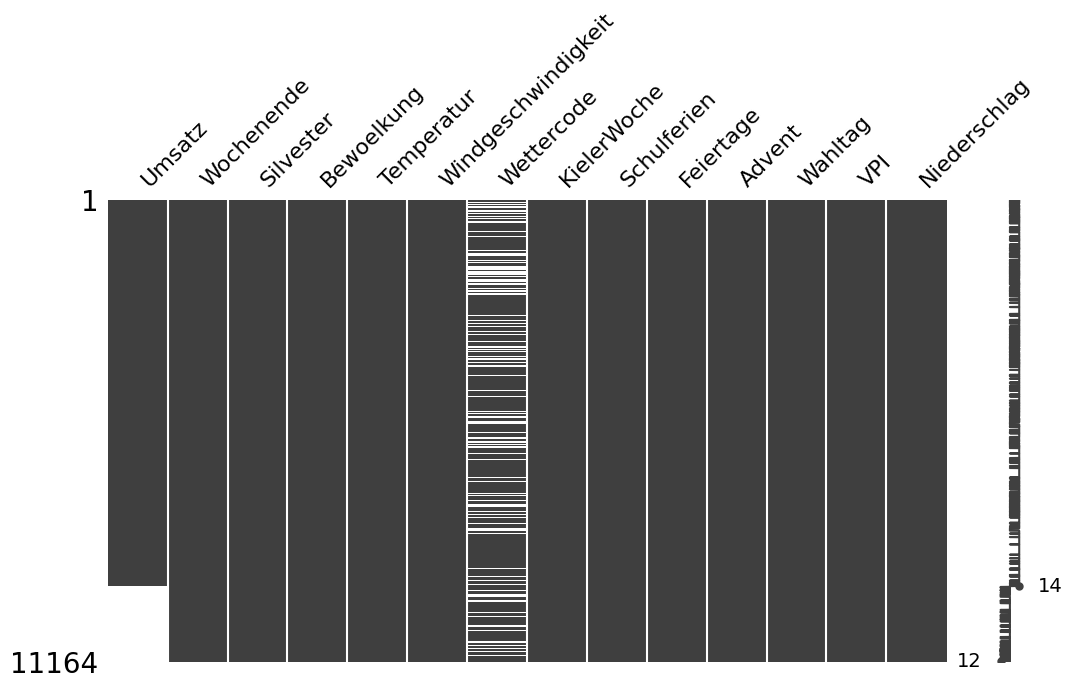

In [7]:
cols = ['Bewoelkung', 'Temperatur', 'Windgeschwindigkeit']
nan_masks = {col: data[col].isna().astype(int) for col in cols}
# Use all columns to find neighbors, but only impute missing values in the specified columns
data_for_impute = data.drop(columns=['Datum', 'id', 'Warengruppe'])
imputed_all = fci.KNN().fit_transform(data_for_impute)
imputed_only_df = pd.DataFrame(imputed_all, columns=data_for_impute.columns)
imputed_df = data_for_impute.copy()
imputed_df[cols] = pd.DataFrame(imputed_all, columns=data_for_impute.columns)[cols]
msno.matrix(imputed_df, figsize=(12, 6), sparkline=True)

In [8]:
print("Correlation in original Data: ", data['Temperatur'].corr(data['Umsatz'], method='pearson'))
print("Correlation in imputed Data: ", imputed_df['Temperatur'].corr(imputed_df['Umsatz'], method='pearson'))

Correlation in original Data:  0.22293543679239144
Correlation in imputed Data:  0.22305205914496967


In [9]:
execute = True

if execute:
    imputed_df[['id', 'Datum', 'Warengruppe']] = data[['id', 'Datum', 'Warengruppe']]
    imputed_df['mask_Temperatur_Windgeschwindigkeit'] = nan_masks['Temperatur']
    imputed_df['mask_Bewoelkung'] = nan_masks['Bewoelkung']

<Axes: >

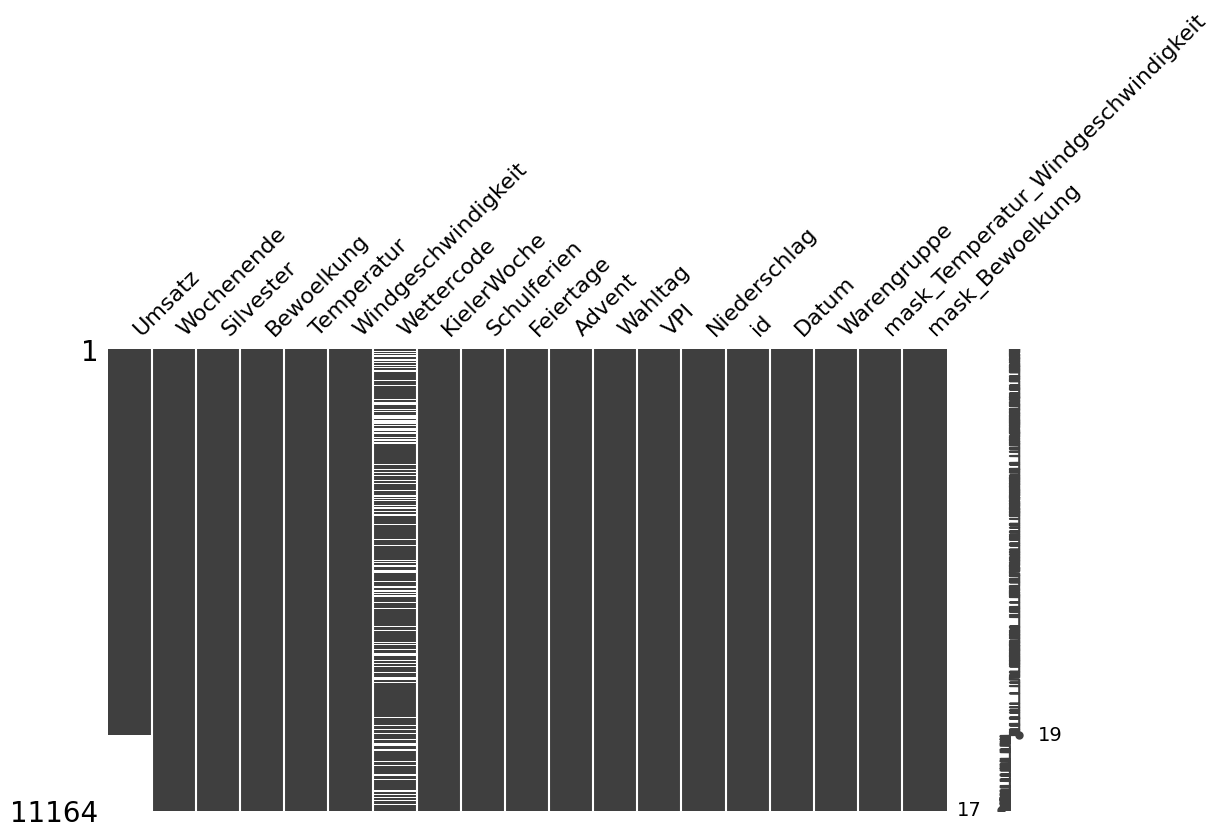

In [10]:
msno.matrix(imputed_df, figsize=(12, 6), sparkline=True)

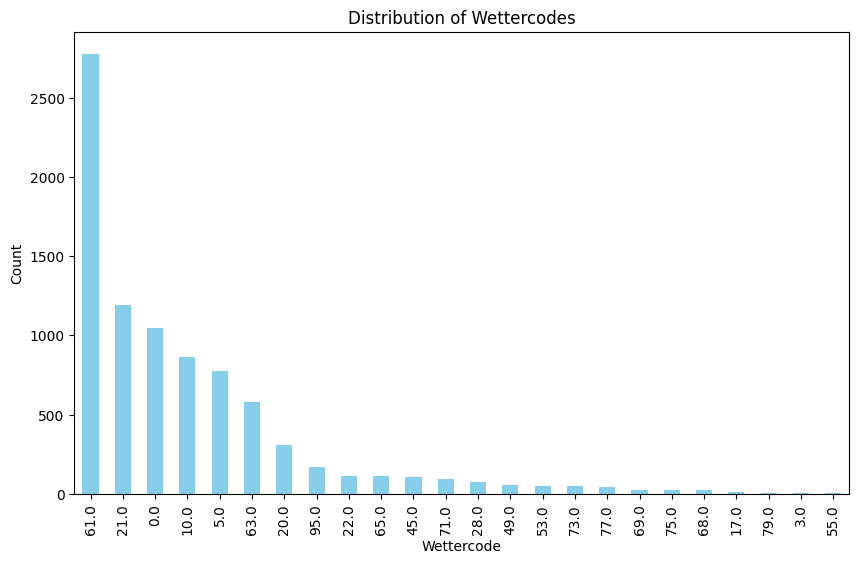

In [11]:
imputed_df['Wettercode'].value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.xlabel('Wettercode')
plt.ylabel('Count')
plt.title('Distribution of Wettercodes')
plt.show()

<Axes: >

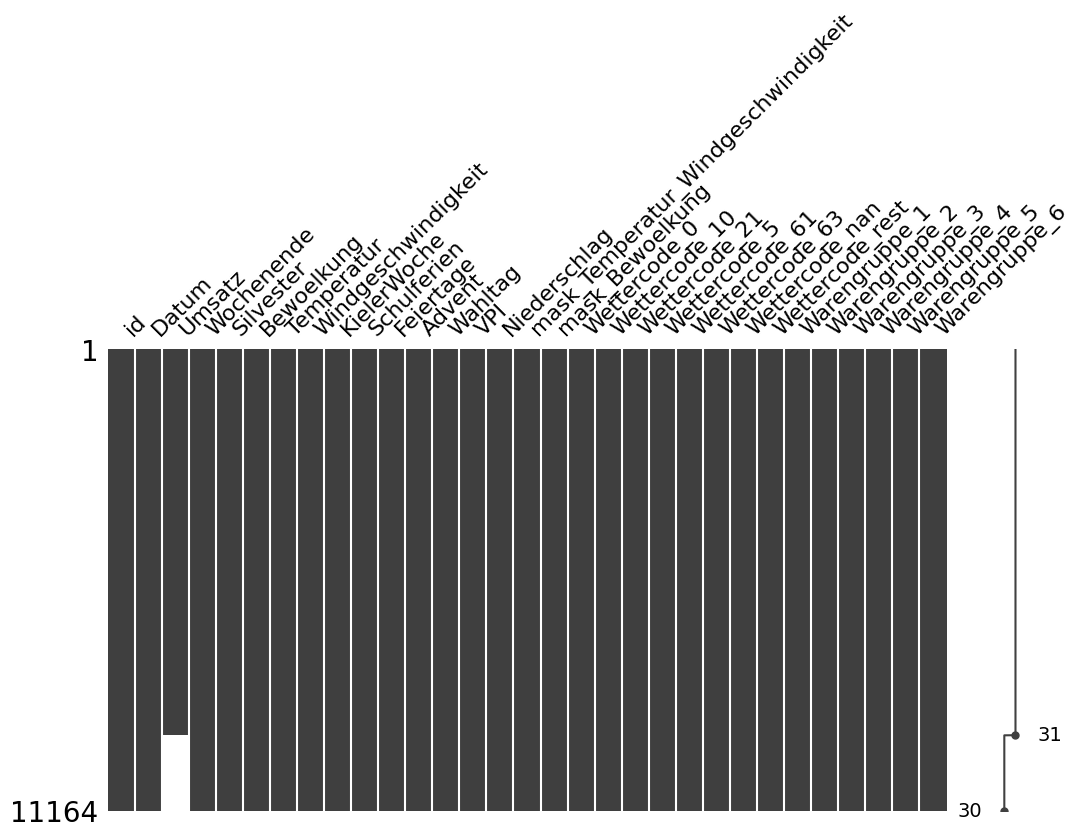

In [12]:
weathercode_map = {
    61: 'Wettercode_61',
    21: 'Wettercode_21',
    0: 'Wettercode_0',
    10: 'Wettercode_10',
    5: 'Wettercode_5',
    63: 'Wettercode_63'
}

def map_weathercode(val):
    if pd.isna(val):
        return 'Wettercode_nan'
    return weathercode_map.get(val, 'Wettercode_rest')

imputed_df['Wettercode_cat'] = imputed_df['Wettercode'].apply(map_weathercode)
weathercode_dummies = pd.get_dummies(imputed_df['Wettercode_cat']).astype(int)
imputed_df = pd.concat([imputed_df, weathercode_dummies], axis=1)

cols_first = ["id", "Datum", "Warengruppe"]
other_cols = [col for col in imputed_df.columns if col not in cols_first]
imputed_df = imputed_df[cols_first + other_cols]

# One-hot encode 'Warengruppe' and add to imputed_df
warengruppe_dummies = pd.get_dummies(imputed_df['Warengruppe'], prefix="Warengruppe", drop_first=False, dtype=int)
imputed_df = pd.concat([imputed_df, warengruppe_dummies], axis=1)

imputed_df = imputed_df.drop(columns=["Warengruppe", "Wettercode", "Wettercode_cat"])

msno.matrix(imputed_df, figsize=(12, 6), sparkline=True)

In [13]:
imputed_df.to_csv("data_after_imputation.csv", index=False)